**Analisis Segmentasi dan Prediksi Kualitas Pembangunan Daerah Berbasis Data Sosial-Ekonomi Indonesia**

## Pembagian Tugas

1. Anggota 1: Data preparation (Radiv)
2. Anggota 2: EDA dan visualisasi (Imanuel)
3. Anggota 3: K-Means clustering (Zhafir)
4. Anggota 4: Random Forest, evaluasi, dan hasil akhir (Naufal)

# Bagian Anggota 1: Data Preparation

## 1. Import library

In [115]:
import pandas as pd
import numpy as np

## 2. Load dataset

In [116]:
df = pd.read_csv("2021socio_economic_indonesia.csv")
df.head()

,province,cities_reg,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
0,Aceh,Simeulue,18.98,2.275,65.240,9.48,7148
1,Aceh,Aceh Singkil,20.36,2.425,67.355,8.68,8776
2,Aceh,Aceh Selatan,13.18,5.531,64.360,8.88,8180
3,Aceh,Aceh Tenggara,13.41,5.063,68.155,9.67,8030
4,Aceh,Aceh Timur,14.45,10.616,68.705,8.21,8577


## 3. Cek struktur data

In [117]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   province               514 non-null    object 
 1   cities_reg             514 non-null    object 
 2   poorpeople_percentage  514 non-null    float64
 3   reg_gdp                514 non-null    float64
 4   life_exp               514 non-null    float64
 5   avg_schooltime         514 non-null    float64
 6   exp_percap             514 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 28.2+ KB


(514, 7)

## 4. Cek missing value

In [118]:
df.isnull().sum()

province                 0
cities_reg               0
poorpeople_percentage    0
reg_gdp                  0
life_exp                 0
avg_schooltime           0
exp_percap               0
dtype: int64

## 5. Cek duplikasi

In [119]:
df.duplicated().sum()

np.int64(0)

## 6. Cleaning data

In [120]:
df = df.drop_duplicates()
df = df.dropna()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)

## 7. Pilih fitur utama

In [121]:
fitur_utama = [
    "poorpeople_percentage",
    "avg_schooltime",
    "life_exp",
    "exp_percap"
]

## 8. Validasi tipe data dan pastikan fitur numerik

In [122]:
for col in fitur_utama:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=fitur_utama)
print("Tipe data fitur utama:")
print(df[fitur_utama].dtypes)

Tipe data fitur utama:
poorpeople_percentage    float64
avg_schooltime           float64
life_exp                 float64
exp_percap                 int64
dtype: object


# Bagian Anggota 2: EDA dan Visualisasi

## 1. Import library

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Statistik deskriptif

In [124]:
df.describe()

,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
count,514.000000,514.000000,514.000000,514.000000,514.000000
mean,12.273152,34.798333,69.619076,8.436615,10324.787938
std,7.458703,84.155498,3.455911,1.630842,2717.144186
min,2.380000,1.042000,55.370000,1.420000,3976.000000
25%,7.150000,5.587500,67.336250,7.510000,8574.000000
50%,10.455000,13.068500,69.922500,8.305000,10196.500000
75%,14.887500,28.849500,72.018750,9.337500,11719.000000
max,41.660000,819.000000,77.855000,12.830000,23888.000000


## 3. Distribusi kemiskinan

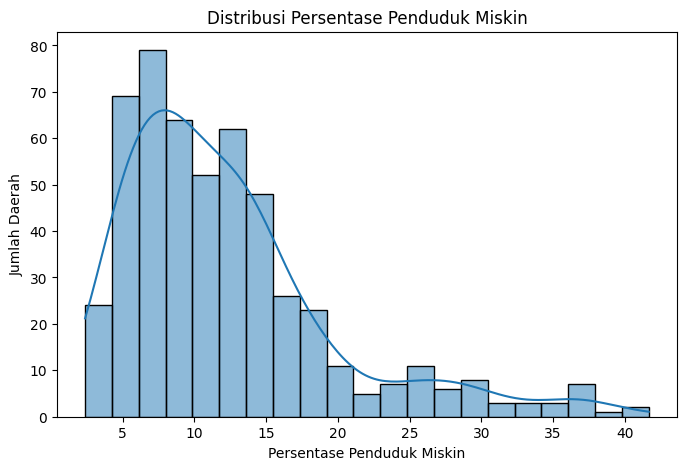

In [125]:
plt.figure(figsize=(8,5))
sns.histplot(df["poorpeople_percentage"], kde=True)
plt.title("Distribusi Persentase Penduduk Miskin")
plt.xlabel("Persentase Penduduk Miskin")
plt.ylabel("Jumlah Daerah")
plt.show()

## 4. Top 10 daerah dengan kemiskinan tertinggi

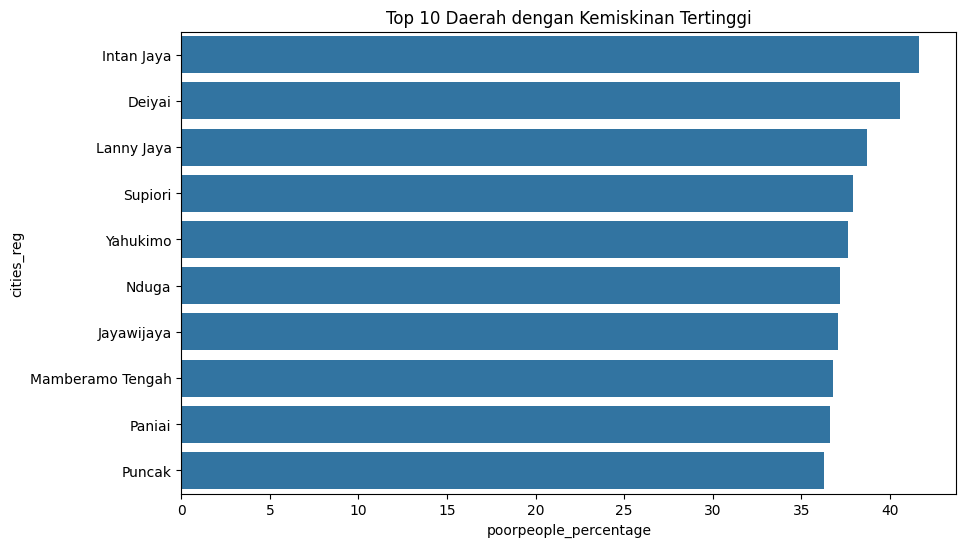

In [126]:
top_miskin = df.sort_values(
    "poorpeople_percentage",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_miskin,
    x="poorpeople_percentage",
    y="cities_reg"
)
plt.title("Top 10 Daerah dengan Kemiskinan Tertinggi")
plt.show()

## 5. Scatter plot pendidikan vs pengeluaran

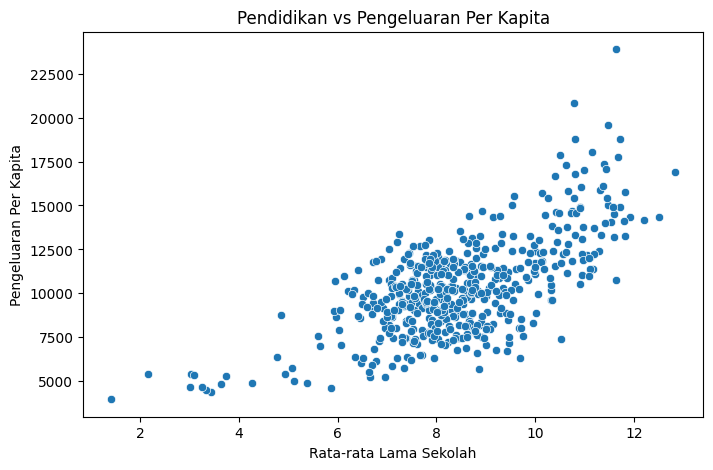

In [127]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="avg_schooltime",
    y="exp_percap"
)
plt.title("Pendidikan vs Pengeluaran Per Kapita")
plt.xlabel("Rata-rata Lama Sekolah")
plt.ylabel("Pengeluaran Per Kapita")
plt.show()

## 6. Scatter plot kemiskinan vs pengeluaran

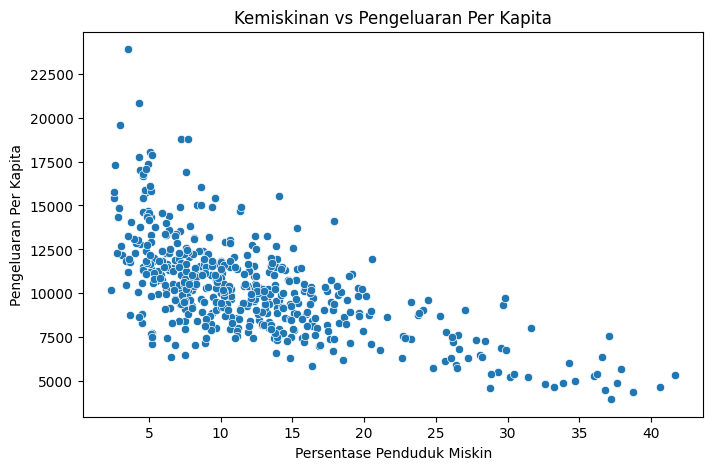

In [128]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="poorpeople_percentage",
    y="exp_percap"
)
plt.title("Kemiskinan vs Pengeluaran Per Kapita")
plt.xlabel("Persentase Penduduk Miskin")
plt.ylabel("Pengeluaran Per Kapita")
plt.show()

## 7. Heatmap korelasi

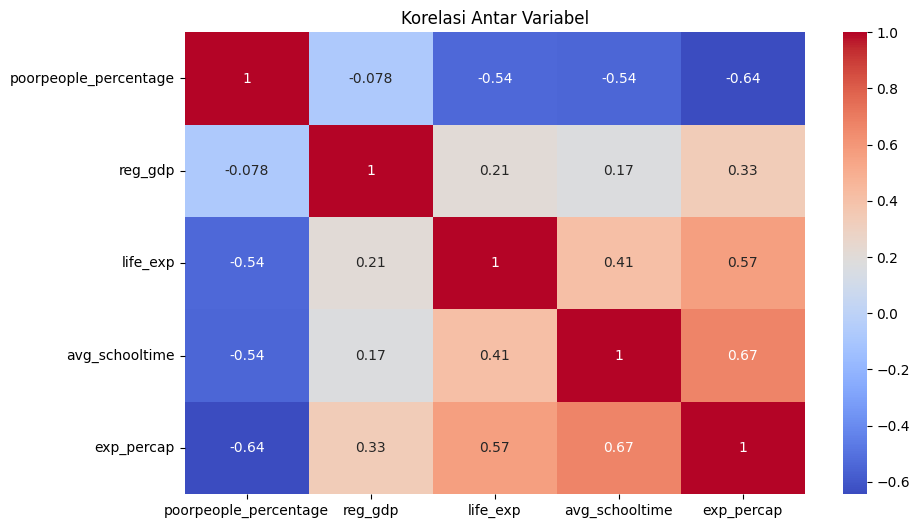

In [129]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Korelasi Antar Variabel")
plt.show()

# Bagian Anggota 3: K-Means Clustering

## 1. Import library

In [130]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Pilih fitur clustering

In [131]:
features_cluster = [
    "poorpeople_percentage",
    "life_exp",
    "avg_schooltime",
    "exp_percap"
]

## 3. Standardisasi data

In [132]:
X_cluster = df[features_cluster]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

## 4. Elbow Method

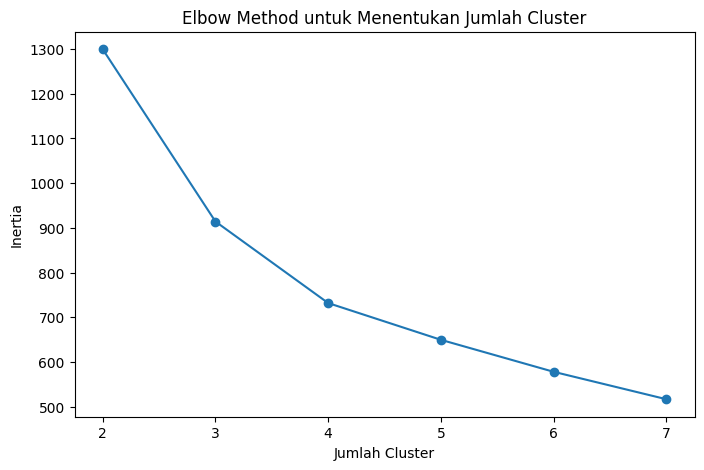

In [133]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 8), inertia, marker="o")
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.show()

## 5. Silhouette Score untuk berbagai nilai k

k=2 -> Silhouette Score: 0.3287
k=3 -> Silhouette Score: 0.3496
k=4 -> Silhouette Score: 0.2846
k=5 -> Silhouette Score: 0.2498
k=6 -> Silhouette Score: 0.2506
k=7 -> Silhouette Score: 0.2444


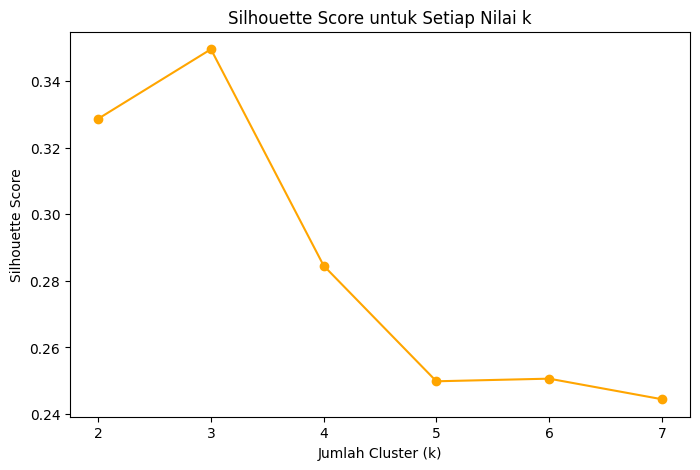

In [134]:
silhouette_scores = []

for k in range(2, 8):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score_temp = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score_temp)
    print(f"k={k} -> Silhouette Score: {score_temp:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2, 8), silhouette_scores, marker="o", color="orange")
plt.title("Silhouette Score untuk Setiap Nilai k")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 8))
plt.show()

## 6. Jalankan K-Means dengan k=3

In [135]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df["cluster"])
print("Silhouette Score (k=3):", round(score, 4))

Silhouette Score (k=3): 0.3496


## 7. Lihat jumlah daerah per cluster

In [136]:
df["cluster"].value_counts()

cluster
0    332
1    123
2     59
Name: count, dtype: int64

## 8. Visualisasi jumlah daerah per cluster

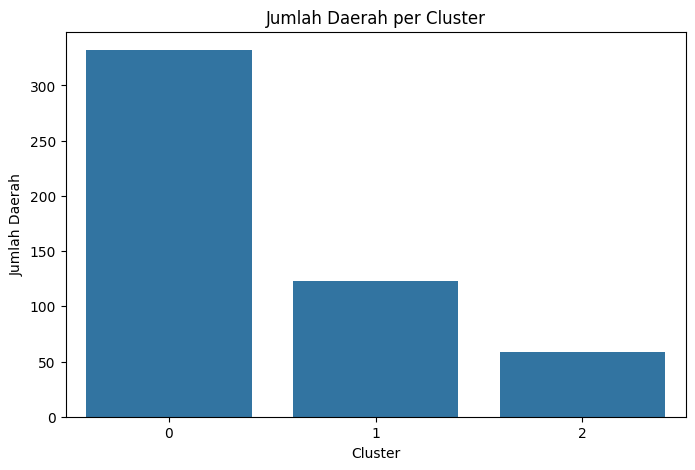

In [137]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="cluster")
plt.title("Jumlah Daerah per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Daerah")
plt.show()

## 9. Ringkasan karakteristik cluster

In [138]:
cluster_summary = df.groupby("cluster")[features_cluster].mean()
print("Rata-rata indikator per cluster:")
cluster_summary

Rata-rata indikator per cluster:


,poorpeople_percentage,life_exp,avg_schooltime,exp_percap
cluster,,,,
0,11.295633,69.362319,8.035843,9763.484940
1,7.186504,72.650528,10.406260,13650.211382
2,28.378136,64.744068,6.585593,6550.644068


## 10. Interpretasi dan pelabelan cluster

In [139]:
from sklearn.preprocessing import MinMaxScaler as MMS

cluster_means = df.groupby("cluster")[features_cluster].mean()

scaler_label = MMS()
cluster_means_norm = pd.DataFrame(
    scaler_label.fit_transform(cluster_means),
    columns=features_cluster,
    index=cluster_means.index
)

cluster_means_norm["poorpeople_percentage"] = 1 - cluster_means_norm["poorpeople_percentage"]

cluster_means_norm["composite_score"] = cluster_means_norm.mean(axis=1)

print("Composite score per cluster (berdasarkan semua indikator):")
print(cluster_means_norm[["composite_score"]].round(4))
print()

sorted_by_composite = cluster_means_norm["composite_score"].sort_values().index.tolist()

label_map = {
    sorted_by_composite[0]: "Pembangunan Rendah",
    sorted_by_composite[1]: "Pembangunan Sedang",
    sorted_by_composite[2]: "Pembangunan Tinggi"
}

df["label_cluster"] = df["cluster"].map(label_map)

print("Pemetaan cluster ke label:")
for k, v in label_map.items():
    print(f"  Cluster {k} -> {v} (composite score: {cluster_means_norm.loc[k, 'composite_score']:.4f})")


Composite score per cluster (berdasarkan semua indikator):
         composite_score
cluster                 
0                 0.5556
1                 1.0000
2                -0.0000

Pemetaan cluster ke label:
  Cluster 2 -> Pembangunan Rendah (composite score: -0.0000)
  Cluster 0 -> Pembangunan Sedang (composite score: 0.5556)
  Cluster 1 -> Pembangunan Tinggi (composite score: 1.0000)


## 11. Tabel ringkasan cluster dengan label

In [140]:
cluster_labeled_summary = df.groupby("label_cluster")[features_cluster].mean().round(2)
print("Rata-rata indikator per kategori pembangunan:")
cluster_labeled_summary

Rata-rata indikator per kategori pembangunan:


,poorpeople_percentage,life_exp,avg_schooltime,exp_percap
label_cluster,,,,
Pembangunan Rendah,28.38,64.74,6.59,6550.64
Pembangunan Sedang,11.30,69.36,8.04,9763.48
Pembangunan Tinggi,7.19,72.65,10.41,13650.21


## 12. Visualisasi scatterplot cluster dengan centroid

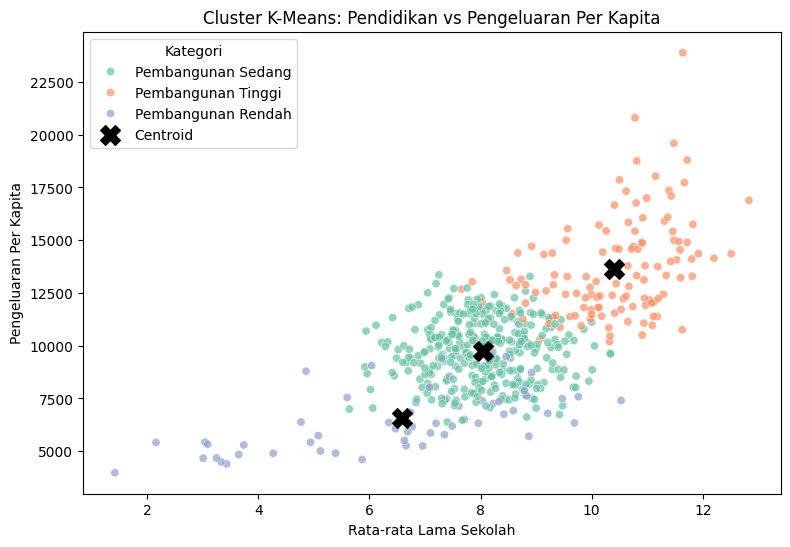

In [141]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=features_cluster)
centroids_df["cluster"] = range(3)
centroids_df["label_cluster"] = centroids_df["cluster"].map(label_map)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="avg_schooltime",
    y="exp_percap",
    hue="label_cluster",
    palette="Set2",
    alpha=0.7
)

plt.scatter(
    centroids_df["avg_schooltime"],
    centroids_df["exp_percap"],
    marker="X",
    s=200,
    c="black",
    zorder=5,
    label="Centroid"
)

plt.title("Cluster K-Means: Pendidikan vs Pengeluaran Per Kapita")
plt.xlabel("Rata-rata Lama Sekolah")
plt.ylabel("Pengeluaran Per Kapita")
plt.legend(title="Kategori")
plt.show()

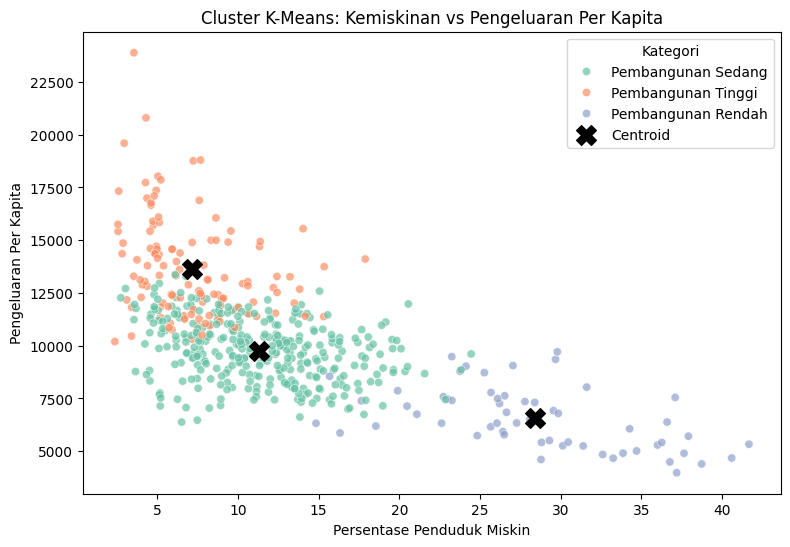

In [142]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="poorpeople_percentage",
    y="exp_percap",
    hue="label_cluster",
    palette="Set2",
    alpha=0.7
)

plt.scatter(
    centroids_df["poorpeople_percentage"],
    centroids_df["exp_percap"],
    marker="X",
    s=200,
    c="black",
    zorder=5,
    label="Centroid"
)

plt.title("Cluster K-Means: Kemiskinan vs Pengeluaran Per Kapita")
plt.xlabel("Persentase Penduduk Miskin")
plt.ylabel("Pengeluaran Per Kapita")
plt.legend(title="Kategori")
plt.show()

# Bagian Anggota 4: Random Forest dan Evaluasi

## 1. Import library

In [143]:
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)
from itertools import cycle

## 2. Buat target klasifikasi untuk Random Forest

In [144]:
scaler_mm = MinMaxScaler()
scaled_rf = pd.DataFrame(
    scaler_mm.fit_transform(df[fitur_utama]),
    columns=fitur_utama,
    index=df.index
)


scaled_rf["poorpeople_percentage"] = 1 - scaled_rf["poorpeople_percentage"]
df["skor_pembangunan"] = scaled_rf.mean(axis=1)


df["target_kategori_pembangunan"] = pd.qcut(
    df["skor_pembangunan"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

print("Distribusi target_kategori_pembangunan:")
print(df["target_kategori_pembangunan"].value_counts())


Distribusi target_kategori_pembangunan:
target_kategori_pembangunan
Rendah    172
Sedang    171
Tinggi    171
Name: count, dtype: int64


## 3. Tentukan fitur dan target

In [145]:
features_model = [
    "poorpeople_percentage",
    "avg_schooltime",
    "life_exp",
    "exp_percap"
]

X = df[features_model]
y = df["target_kategori_pembangunan"]

## 4. Split data train-test

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. Buat dan latih model Random Forest

In [147]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 6. Prediksi dan evaluasi

In [148]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.912621359223301

              precision    recall  f1-score   support

      Rendah       0.97      0.89      0.93        35
      Sedang       0.84      0.91      0.87        34
      Tinggi       0.94      0.94      0.94        34

    accuracy                           0.91       103
   macro avg       0.92      0.91      0.91       103
weighted avg       0.92      0.91      0.91       103



## 7. Confusion matrix

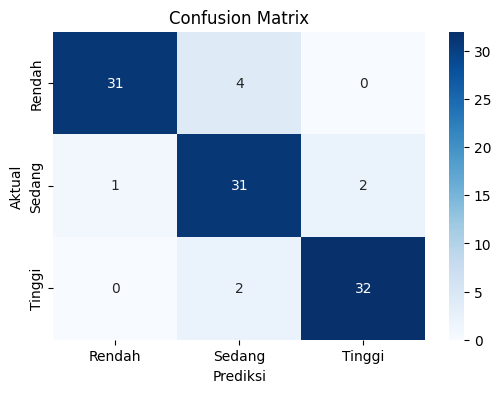

In [149]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## 8. Feature importance

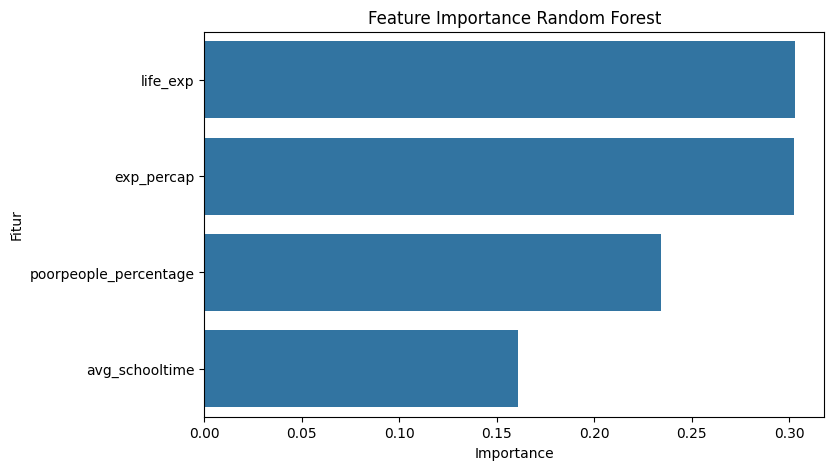

,Fitur,Importance
2,life_exp,0.302787
3,exp_percap,0.302427
0,poorpeople_percentage,0.234071
1,avg_schooltime,0.160716


In [150]:
importance = pd.DataFrame({
    "Fitur": features_model,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Importance", y="Fitur")
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

importance

## 9. ROC AUC - One-vs-Rest Multiclass

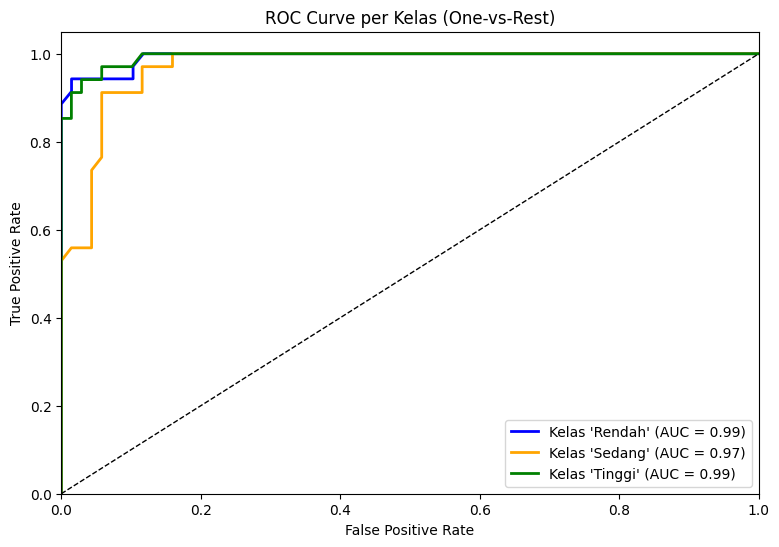

AUC per kelas:
  Rendah: 0.9933
  Sedang: 0.9706
  Tinggi: 0.9934

ROC AUC Macro-Average: 0.9858


In [151]:
classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_prob = model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

plt.figure(figsize=(9, 6))
colors = cycle(["blue", "orange", "green"])

for cls, color in zip(classes, colors):
    plt.plot(
        fpr[cls],
        tpr[cls],
        color=color,
        lw=2,
        label=f"Kelas '{cls}' (AUC = {roc_auc[cls]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Kelas (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

print("AUC per kelas:")
for cls in classes:
    print(f"  {cls}: {roc_auc[cls]:.4f}")

macro_auc = np.mean(list(roc_auc.values()))
print(f"\nROC AUC Macro-Average: {macro_auc:.4f}")

## 10. Simpan hasil akhir

In [152]:
df.to_csv("socio_economic_final.csv", index=False)
print("Dataset final berhasil disimpan ke socio_economic_final.csv")

Dataset final berhasil disimpan ke socio_economic_final.csv
